# NASA Rotor 37 Validation Notebook

This notebook is focused on validation of the `MultistageFanSolver` against **NASA Rotor 37**. Unlike the previous validation against Report No. 729, Rotor 37 operates in a high-speed regime, where compressible inviscid assumptions generally hold better despite significant shock structures. This notebook will compare solver pressure and temperature ratios to literature values.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

import pandas as pd
import math
import numpy as np
from axialfans.fan_solver import MultistageFanSolver, State
import matplotlib.pyplot as plt

Project root: C:\Users\yokit\Documents\Sean\VSCode\axialfans


In [2]:
rho0 = 1.229
P0 = 101325
T0 = 288.15
R = 287.053
gamma = 1.4
cp = 1005

## Retrieve Values

The original paper provides the following design parameters, which we will convert into the necessary inputs for the `MultistageFanSolver`.

| PARAMETER | DESIGN VALUE |
| :--- | :--- |
| Rotor Total Pressure Ratio | 2.106 |
| Rotor Total Temperature Ratio | 1.270 |
| Rotor Adiabatic Efficiency | 0.877 |
| Rotor Head Rise Coefficient | 0.333 |
| Flow Coefficient | 0.453 |
| Mass Flow, kg/s | 20.188 |
| Rotor Wheel Speed, rpm | 17188.7 |
| Rotor Tip Speed, m/s | 454.14 |
| Hub / Tip Radius Ratio | 0.70 |
| Rotor Aspect Ratio | 1.19 |
| Number of Rotor Blades | 36 |
| Blading Type | Multiple Circular Arc (MCA) |

Our goal is to see how accurate the calculated pressure and temperature ratios are in comparison to these literature values.

In [3]:
eta = 0.877
mass_flow = 20.188  # kg/s (from NASA data)

omega = 17188.7 * 2 * math.pi / 60
print("Omega = ", omega)

rp = 454.14 / omega
print("r+ = ", rp)

rm = 0.70 * rp
print("r- = ", rm)

area = math.pi * (rp**2 - rm**2)

vax0 = mass_flow / rho0 / area
print("vax0 = ", vax0)

M = 200 # Solver grid resolution

beta_hub = 38.9 - 17.0 * (rp - rm)
beta_arr = np.linspace(beta_hub, 38.9, M)
print("Beta Hub = ", beta_arr[0])
print("Beta Tip = ", beta_arr[-1])


Omega =  1799.996454825296
r+ =  0.2523004969162997
r- =  0.17661034784140978
vax0 =  161.05905724198735
Beta Hub =  37.61326746572687
Beta Tip =  38.9


## Reynolds Number Calculation

The Reynolds number was computed as $Re = \frac{\rho U L}{\mu}$ where $U = \omega r_{-}$ is the characteristic tangential velocity at the minimum radius (to be conservative) and $L = r_{+} - r_{-}$ is the characteristic length scale taken as the blade chord (radial span).


In [4]:
mu = 1.73e-5  # Pa·s, air dynamic viscosity
chord = rp - rm  # m, blade chord length
U = omega * rm

Re = rho0 * U * chord / mu
print("Re = ", Re)

Re =  1709357.6344531153


## Slip Factor (Qiu et al.)

The slip factor $\sigma$ depends on exit flow coefficient $\phi_2 = \bar{v}_{ax,exit}/(\omega R_2)$, which is itself a solver output — creating a circular dependency.

We resolve this via **Picard iteration**: starting from $\sigma_0 = 0.90$, run the solver, compute $\phi_2$ from the area-averaged exit axial velocity, update $\sigma$ from the Qiu et al. linearized correlation, and repeat until $|\Delta\sigma| < 10^{-6}$.

**Pressure ratio is blinded throughout** — convergence is enforced on the slip factor residual alone, eliminating bias toward the NASA experimental value.

The Qiu correlation (Fig. 5C solid line) linearized from published endpoints:

$$\sigma(\phi_2) = 1.0043 - 0.2143\,\phi_2$$

For cases without blade twist data, the empirical model $\sigma = 1 - C/Z$ is used instead, where $C$ is calibrated to NASA Rotor 37. Sensitivity analysis confirms that slip model choice is not the dominant error source — geometric uncertainty and viscous effects dominate.

In [5]:
def qiu_sigma(vax_exit_avg, omega, R2):
    phi2 = vax_exit_avg / (omega * R2)
    return float(1.0043 - 0.2143 * phi2)

def picard_sigma(solver_factory, inlet, omega, R2, sigma0=0.90, tol=1e-6, max_iter=50):
    sigma = sigma0
    for i in range(max_iter):
        solver = solver_factory(sigma)
        states = solver.solve(inlet, verbose=False)
        sigma_new = qiu_sigma(states[1].vax_avg, omega, R2)
        if abs(sigma_new - sigma) < tol:
            return sigma_new, states, i + 1
        sigma = sigma_new
    return sigma, states, max_iter

In [6]:
def make_solver(sigma):
    return MultistageFanSolver(N=1, M=M, direction=[1],
        sigma=sigma, omega=omega, beta=beta_arr,
        rp=rp, rm=rm, eta=0.877)

def make_inlet(M=M, vax=161.0):
    return State(n=0, M=M, rm=rm, rp=rp, T=288.15, P=101325.0,
                 vax=vax, rho=rho0, vtheta=0.0)

sigma_conv, states, n_iters = picard_sigma(make_solver, make_inlet(), omega, R2=rp)
print(f"Converged in {n_iters} iters  sigma={sigma_conv:.4f}  phi2={states[1].vax_avg/(omega*rp):.4f}")

Converged in 4 iters  sigma=0.9572  phi2=0.2198


## Validation — NASA Rotor 37

Pressure ratio and temperature ratio errors relative to NASA experimental data (Reid & Moore, 1978).
All cases use `M=200` radial stations. Slip factor determined via Picard iteration on the Qiu et al. correlation (blinded to pressure ratio).

In [7]:
NASA_PR = 2.106
NASA_TR = 1.270

cases = {
    "Uniform β, uniform σ=0.90": dict(beta=38.9, sigma=0.90),
    "Blade twist, uniform σ=0.90": dict(beta=beta_arr, sigma=0.90),
    "Blade twist, Qiu σ (Picard)": dict(beta=beta_arr, sigma=sigma_conv),
}

print(f"{'Case':<35} {'PR':>7} {'PR err':>8} {'TR':>7} {'TR err':>8}")
print("-" * 70)

for label, kwargs in cases.items():
    solver = MultistageFanSolver(
        N=1, M=M, direction=[1],
        omega=omega, rp=rp, rm=rm, eta=0.877,
        **kwargs,
    )
    states = solver.solve(make_inlet(), verbose=False)
    perf = solver.performance()
    pr_err = (perf["PR"] - NASA_PR) / NASA_PR * 100
    tr_err = (perf["TR"] - NASA_TR) / NASA_TR * 100
    print(f"{label:<35} {perf['PR']:>7.4f} {pr_err:>+7.2f}%  {perf['TR']:>7.4f} {tr_err:>+7.2f}%")

Case                                     PR   PR err      TR   TR err
----------------------------------------------------------------------
Uniform β, uniform σ=0.90            2.0154   -4.30%   1.2502   -1.56%
Blade twist, uniform σ=0.90          2.0221   -3.98%   1.2516   -1.45%
Blade twist, Qiu σ (Picard)          2.0640   -1.99%   1.2597   -0.81%


## Grid Convergence Study

Pressure ratio is evaluated at increasing radial resolution $M$ to verify mesh independence. A solution is considered converged when $|\Delta PR / PR| < 0.01\%$ relative to the finest grid.

In [8]:
M_values = [2, 5, 10, 20, 50, 100, 200, 500]
PR_values = []

for M_i in M_values:
    beta_i = np.linspace(38.9 - 17.0*(rp-rm), 38.9, M_i)
    solver_i = MultistageFanSolver(
        N=1, M=M_i, direction=[1],
        sigma=sigma_conv, omega=omega,
        beta=beta_i, rp=rp, rm=rm, eta=0.877,
    )
    inlet_i = State(n=0, M=M_i, rm=rm, rp=rp,
                    T=T0, P=P0, vax=vax0, rho=rho0, vtheta=0.0)
    states_i = solver_i.solve(inlet_i, verbose=False)
    PR_values.append(solver_i.performance()["PR"])

PR_ref = PR_values[-1]

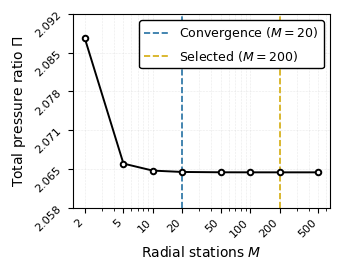

Convergence threshold: M = 20


In [9]:
fig, ax = plt.subplots(figsize=(3.5, 2.8))

PR_ref = PR_values[-1]

converged_M = None
for i in range(len(M_values) - 1):
    if abs(PR_values[i+1] - PR_values[i]) / PR_values[i] < 1e-4:
        converged_M = M_values[i]
        break

ax.semilogx(M_values, PR_values, 'o-',
            color='black', linewidth=1.4, markersize=4,
            markerfacecolor='white', markeredgewidth=1.4, zorder=3)
ax.axvline(converged_M, color='#2471a3', linewidth=1.2,
           linestyle='--', label=f'Convergence ($M={converged_M}$)', zorder=2)
ax.axvline(200, color='#d4ac0d', linewidth=1.2,
           linestyle='--', label='Selected ($M=200$)', zorder=2)

ax.set_xlabel('Radial stations $M$', fontsize=10)
ax.set_ylabel('Total pressure ratio $\\Pi$', fontsize=10)
ax.set_xticks(M_values)
ax.set_xticklabels(M_values, fontsize=8, rotation=45, ha='right')

y_min = min(PR_values) * 0.997
y_max = max(PR_values) * 1.002
ax.set_ylim([y_min, y_max])
y_ticks = np.linspace(y_min, y_max, 6)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{y:.3f}' for y in y_ticks], fontsize=8, rotation=45, ha='right')

ax.legend(fontsize=9, framealpha=1.0, edgecolor='black')
ax.grid(True, which='both', linestyle=':', linewidth=0.4, alpha=0.5)

fig.tight_layout()
plt.savefig('figures/rotor37_convergence.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Convergence threshold: M = {converged_M}")

## Radial Contour Plots — Rotor Exit

Annular cross-section of the rotor exit plane ($n=1$), colored by flow quantity. Each plot shows the full hub-to-tip radial distribution resolved across $M=200$ stations.

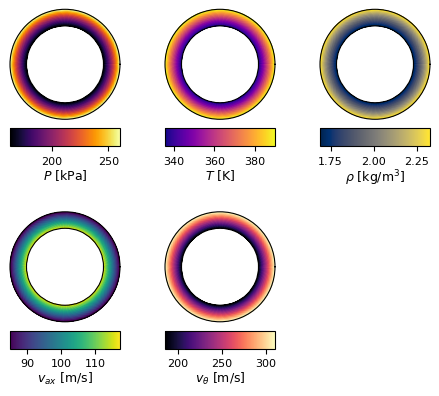

In [10]:
from matplotlib.colors import Normalize

exit_state = states[-1]
r_vals = exit_state.r  # (M,)

a_exit = np.sqrt(gamma * R * exit_state.T)
V_rel  = np.sqrt(exit_state.vax**2 + exit_state.vtheta**2)
Mach_r = V_rel / a_exit

quantities = [
    (exit_state.P / 1e3,    r'$P$ [kPa]',       'inferno'),
    (exit_state.T,           r'$T$ [K]',          'plasma'),
    (exit_state.rho,         r'$\rho$ [kg/m$^3$]',  'cividis'),
    (exit_state.vax,         r'$v_{ax}$ [m/s]',     'viridis'),
    (exit_state.vtheta,      r'$v_{\theta}$ [m/s]', 'magma'),
]

theta = np.linspace(0, 2 * np.pi, 361)  # (361,)
# For gouraud we need Q same shape as R, THETA
R_grid, THETA_grid = np.meshgrid(r_vals, theta)  # both (361, M)

nrows, ncols = 2, 3
panel_w = 0.22
panel_h = 0.34
cbar_h  = 0.04
gap_x   = 0.09
gap_y   = 0.16

row_y = [0.55, 0.10]
col_x = [0.05 + i * (panel_w + gap_x) for i in range(ncols)]

fig = plt.figure(figsize=(5, 4.5))

for idx, (q, label, cmap) in enumerate(quantities):
    row = idx // ncols
    col = idx  % ncols
    x0  = col_x[col]
    y0  = row_y[row]

    ax = fig.add_axes([x0, y0, panel_w, panel_h], projection='polar')

    # Q must be (361, M) matching THETA_grid and R_grid
    Q = np.tile(q, (len(theta), 1))  # (361, M)

    mesh = ax.pcolormesh(THETA_grid, R_grid, Q,
                         cmap=cmap, shading='gouraud')

    ax.set_rorigin(0)
    ax.set_ylim([exit_state.rm, exit_state.rp])
    ax.set_yticklabels([])
    ax.set_xticklabels([])
    ax.grid(False)

    pos   = ax.get_position()
    cb_ax = fig.add_axes([pos.x0, pos.y0 - cbar_h - 0.02,
                          pos.width, cbar_h])
    cbar  = fig.colorbar(mesh, cax=cb_ax, orientation='horizontal')
    cbar.ax.tick_params(labelsize=8)
    cbar.set_label(label, fontsize=9, labelpad=1)

# 6th slot — invisible, nothing drawn

plt.savefig('figures/rotor37_annular_contours.png', dpi=300, bbox_inches='tight')
plt.show()

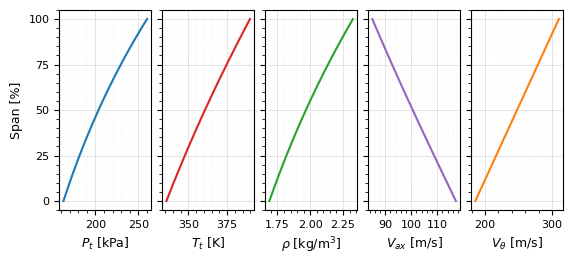

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Data Extraction
exit_state = states[-1]
span = np.linspace(0, 100, exit_state.M) 

quantities = [
    (exit_state.P / 1e3,    r'$P_t$ [kPa]',      '#1f77b4'),
    (exit_state.T,          r'$T_t$ [K]',        '#d62728'),
    (exit_state.rho,         r'$\rho$ [kg/m$^3$]', '#2ca02c'),
    (exit_state.vax,         r'$V_{ax}$ [m/s]',   '#9467bd'),
    (exit_state.vtheta,      r'$V_{\theta}$ [m/s]', '#ff7f0e'),
]

# Using a slightly narrower aspect ratio to make them look more integrated
fig, axes = plt.subplots(1, 5, figsize=(6.5, 2.6), sharey=True)

for i, (q, label, color) in enumerate(quantities):
    ax = axes[i]
    ax.plot(q, span, color=color, linewidth=1.5)
    
    # AIAA Styling
    ax.set_xlabel(label, fontsize=9, labelpad=4)
    ax.tick_params(axis='both', labelsize=8)
    
    # Tight Grid
    ax.grid(visible=True, which='major', linestyle='-', linewidth=0.5, color='0.85')
    ax.minorticks_on()
    ax.grid(visible=True, which='minor', linestyle=':', linewidth=0.3, color='0.9')
    
    if i == 0:
        ax.set_ylabel('Span [%]', fontsize=9)
        ax.set_yticks([0, 25, 50, 75, 100])

# Reduce padding between subplots significantly
# wspace=0.1 to 0.15 is usually the "sweet spot" for shared Y-axis plots
plt.subplots_adjust(wspace=0.12)

# Save high-res for the paper
plt.savefig('figures/rotor37_radial_profiles.png', dpi=300, bbox_inches='tight')
plt.show()